# (노트) Boxplot 
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [파이썬]

### import

In [8]:
import matplotlib.pyplot as plt 
import numpy as np

### boxplot 

`-` ref: https://matplotlib.org/3.1.1/gallery/pyplots/boxplot_demo_pyplot.html#sphx-glr-gallery-pyplots-boxplot-demo-pyplot-py

#### 전북고예제: 평균은 괜찮은 측정값인가? (통계학과)

`-` 전북고등학교에서 통계학을 수업하는 두 선생님이 있다. 편의상 A 선생님과 B 선생님이라고 하자. A 선생님이 강의한 반의 통계학 점수는 평균 79.1점, B 선생님이 강의한 반의 통계학 점수는 평균 78.3점 이라고 하자. 

`-` 의사결정: A 선생님에게 배운 학생들의 실력이 평균적으로 좋을것이다.

In [9]:
y1=[75,75,76,76,77,77,79,79,79,98] ## A 선생님에게 통계학을 배운 학생의 점수들
y2=[76,76,77,77,78,78,80,80,80,81] ## B 선생님에게 통계학을 배운 학생의 점수들 

In [10]:
np.mean(y1), np.mean(y2)

(79.1, 78.3)

`-` 평균은 A반(=A선생님에게 통계학을 배운 반)이 더 높다. 그런데 98점을 받은 학생때문에 전체 평균이 올라간것이지 나머지 학생들은 모두 B반(=B선생님에게 통계학을 배운 반) 학생들의 점수가 더 높다. 

`-` 단순한 평균비교보다 분포를 비교하는것이 중요함. 분포를 살펴보는 방법중 하나로는 박스플랏이 있다. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f637d37bc40>,
 'caps': [<matplotlib.lines.Line2D at 0x7f637d3083a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f637d37b880>],
 'medians': [<matplotlib.lines.Line2D at 0x7f637d308ac0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f637d308e50>],
 'means': []}

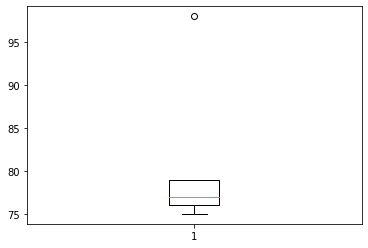

In [76]:
plt.boxplot(y1)

- A반의 boxplot
- 뚝 떨어진 하나의 점은 98점 
- 붉은 선은 중앙값 (평균이 아니라 중앙값) 
- 나머지 점들은 7~80점에 분포되어있다. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f6386868bb0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f638687b310>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f6386868820>],
 'medians': [<matplotlib.lines.Line2D at 0x7f638687ba30>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f638687bdc0>],
 'means': []}

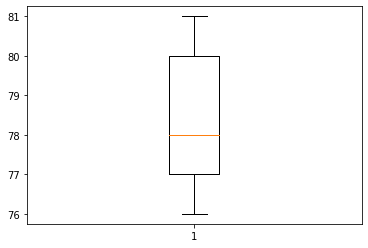

In [12]:
plt.boxplot(y2)

- B반의 boxplot

`-` 따로따로 그리는것은 별로 좋지않은 시각화 방법같다. (한눈에 보이지 않음, y축의 scale도 다름)

`-` 아래와 같이 개선해보자. 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f638685ca60>,
 'caps': [<matplotlib.lines.Line2D at 0x7f63867eb1c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f638685c6d0>,
 'medians': [<matplotlib.lines.Line2D at 0x7f63867eb8e0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f63867ebc70>,
 'means': []}

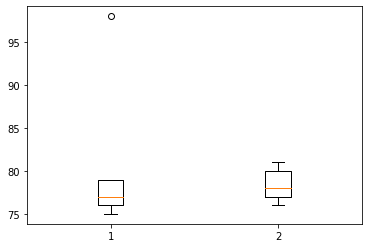

In [13]:
plt.boxplot([y1,y2])

`-` 미적인 요소가 아쉽긴 하지만 이정도는 괜찮다. 

#### 박스플랏이란? (통계학과)

`-` ref: https://towardsdatascience.com/understanding-boxplots-5e2df7bcbd51
 - github: https://github.com/mGalarnyk/Python_Tutorials/blob/master/Statistics/boxplot/box_plot.ipynb

`-` 아래의 그림을 보면서 이해하자. 

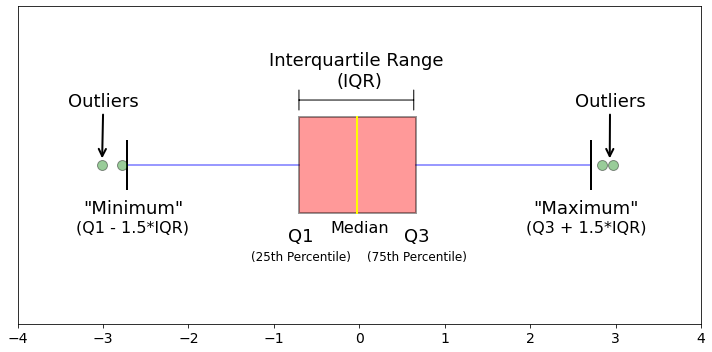

In [56]:
#collapse
np.random.seed(916170)

# connection path is here: https://stackoverflow.com/questions/6146290/plotting-a-line-over-several-graphs
mu, sigma = 0, 1 # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize=(10, 5))

# rectangular box plot
bplot = axes.boxplot(s,
                vert=False,
                patch_artist=True, 
                showfliers=True, # This would show outliers (the remaining .7% of the data)
                positions = [0],
                boxprops = dict(linestyle='--', linewidth=2, color='Black', facecolor = 'red', alpha = .4),
                medianprops = dict(linestyle='-', linewidth=2, color='Yellow'),
                whiskerprops = dict(linestyle='-', linewidth=2, color='Blue', alpha = .4),
                capprops = dict(linestyle='-', linewidth=2, color='Black'),
                flierprops = dict(marker='o', markerfacecolor='green', markersize=10,
                  linestyle='none', alpha = .4),
                widths = .3,
                zorder = 1)   

axes.set_xlim(-4, 4)
plt.xticks(fontsize = 14)

axes.set_yticks([])
axes.annotate(r'',
            xy=(-.73, .205), xycoords='data',
            xytext=(.66, .205), textcoords='data',
            arrowprops=dict(arrowstyle="|-|",
                            connectionstyle="arc3")
            );

axes.text(0, .25, "Interquartile Range \n(IQR)",  horizontalalignment='center', fontsize=18)
axes.text(0, -.21, r"Median", horizontalalignment='center', fontsize=16);
axes.text(2.65, -.15, "\"Maximum\"", horizontalalignment='center', fontsize=18);
axes.text(-2.65, -.15, "\"Minimum\"", horizontalalignment='center', fontsize=18);
axes.text(-.68, -.24, r"Q1", horizontalalignment='center', fontsize=18);
axes.text(-2.65, -.21, r"(Q1 - 1.5*IQR)", horizontalalignment='center', fontsize=16);
axes.text(.6745, -.24, r"Q3", horizontalalignment='center', fontsize=18);
axes.text(.6745, -.30, r"(75th Percentile)", horizontalalignment='center', fontsize=12);
axes.text(-.68, -.30, r"(25th Percentile)", horizontalalignment='center', fontsize=12);
axes.text(2.65, -.21, r"(Q3 + 1.5*IQR)", horizontalalignment='center', fontsize=16);

axes.annotate('Outliers', xy=(2.93,0.015), xytext=(2.52,0.20), fontsize = 18,
            arrowprops={'arrowstyle': '->', 'color': 'black', 'lw': 2},
            va='center');

axes.annotate('Outliers', xy=(-3.01,0.015), xytext=(-3.41,0.20), fontsize = 18,
            arrowprops={'arrowstyle': '->', 'color': 'black', 'lw': 2},
            va='center');

fig.tight_layout()

#### plotly (컴퓨터공학과)

In [48]:
import plotly.express as px
from IPython.display import HTML
import pandas as pd

In [58]:
A=pd.DataFrame({'y':y1,'x':['A']*len(y1)})
B=pd.DataFrame({'y':y2,'x':['B']*len(y2)})
df=pd.concat([A,B],ignore_index=True)

In [59]:
df

,y,x
0,75,A
1,75,A
2,76,A
3,76,A
4,77,A
5,77,A
6,79,A
7,79,A
8,79,A
9,98,A


In [60]:
fig=px.box(data_frame=df,x='x',y='y')
HTML(fig.to_html(include_plotlyjs='cdn',include_mathjax=False))

### histogram

#### 히스토그램이란? 

`-` X축이 변수의 구간, Y축은 그 구간에 포함된 빈도를 의미함 

`-` 예를들면 아래와 같은것 

(array([  10.,   90.,  503., 1534., 2727., 2789., 1662.,  548.,  118.,
          19.]),
 array([-3.79519698, -3.04327907, -2.29136117, -1.53944326, -0.78752536,
        -0.03560745,  0.71631045,  1.46822836,  2.22014626,  2.97206416,
         3.72398207]),
 <BarContainer object of 10 artists>)

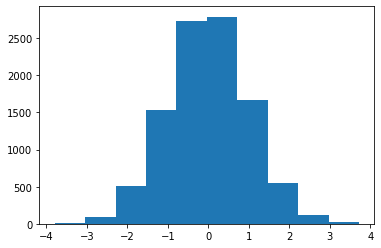

In [83]:
plt.hist(np.random.normal(loc=0,scale=1,size=10000))

#### 전북고예제

`-` 중심경향값, 집중경항치 (Measure of central tendency): 분포의 중심성을 나타내기 위한 값, 예시로는 평균 중앙값등이 있음. 
- https://en.wikipedia.org/wiki/Central_tendency

`-` "평균이 항상 좋은 중심경향값은 아니다"라는 사실은 이해했음. 

`-` 하지만 특수한 상황을 가정하면 평균이 좋은 중심경향값임. 

In [98]:
np.random.seed(43052)
y1=np.random.normal(loc=0,scale=1,size=10000) # 전북고 A반의 통계학 성적이라 생각하자. 
y2=np.random.normal(loc=0.5,scale=1,size=10000) # 전북고 B반의 통계학 성적이라 생각하자. 

In [99]:
np.mean(y1), np.mean(y2)

(-0.011790879905079434, 0.4979147460611458)

In [100]:
(np.mean(y2)-np.mean(y1)).round(3)

0.51

{'whiskers': [<matplotlib.lines.Line2D at 0x7f6375dcd700>,
 'caps': [<matplotlib.lines.Line2D at 0x7f6375dcde50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f6375dcd4c0>,
 'medians': [<matplotlib.lines.Line2D at 0x7f6375ddb5b0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f6375ddb940>,
 'means': []}

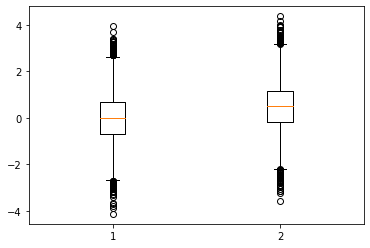

In [101]:
plt.boxplot([y1,y2])

- 분포의 모양은 거의 비슷하다. 

- 이런상황에서는 $B반의 성적 \approx A반의 성적+0.51$ 라고 주장해도 큰 무리가 없을 정도 

`-` 정규분포를 가정하면 앞선예제와 같은 모양이 잘 안나옴. 

`-` 그런데 정규분포인것은 어떻게 아는가? $\to$ 히스토그램을 그려봐서 종모양이 나오는지 살펴보자. 

(array([  1.,   1.,   3.,   0.,   1.,   4.,   5.,  12.,  14.,  26.,  32.,
         52.,  67.,  89., 144., 171., 238., 282., 325., 378., 489., 492.,
        561., 635., 652., 636., 626., 606., 573., 539., 475., 444., 350.,
        250., 232., 172., 137.,  80.,  58.,  47.,  30.,  23.,  17.,  12.,
          9.,   4.,   4.,   0.,   1.,   1.]),
 array([-4.12186916, -3.96068404, -3.79949892, -3.6383138 , -3.47712868,
        -3.31594356, -3.15475844, -2.99357332, -2.8323882 , -2.67120308,
        -2.51001796, -2.34883284, -2.18764772, -2.0264626 , -1.86527748,
        -1.70409236, -1.54290724, -1.38172212, -1.220537  , -1.05935188,
        -0.89816676, -0.73698164, -0.57579652, -0.4146114 , -0.25342628,
        -0.09224116,  0.06894396,  0.23012908,  0.3913142 ,  0.55249932,
         0.71368444,  0.87486956,  1.03605468,  1.1972398 ,  1.35842492,
         1.51961004,  1.68079516,  1.84198028,  2.0031654 ,  2.16435052,
         2.32553564,  2.48672076,  2.64790588,  2.809091  ,  2.97027612,
 

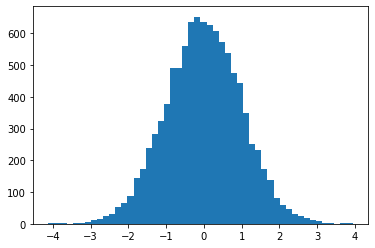

In [112]:
plt.hist(y1,bins=50)

(array([  1.,   0.,   3.,   2.,   4.,   5.,   5.,  10.,  16.,  25.,  33.,
         56.,  74., 116., 119., 152., 244., 272., 351., 362., 438., 509.,
        531., 621., 624., 690., 636., 571., 564., 514., 462., 402., 356.,
        297., 233., 184., 144., 113.,  80.,  55.,  38.,  34.,  21.,  18.,
          4.,   3.,   2.,   4.,   1.,   1.]),
 array([-3.5752867 , -3.4164866 , -3.2576865 , -3.0988864 , -2.9400863 ,
        -2.7812862 , -2.6224861 , -2.463686  , -2.3048859 , -2.1460858 ,
        -1.9872857 , -1.8284856 , -1.6696855 , -1.5108854 , -1.3520853 ,
        -1.1932852 , -1.0344851 , -0.875685  , -0.7168849 , -0.5580848 ,
        -0.3992847 , -0.2404846 , -0.0816845 ,  0.0771156 ,  0.2359157 ,
         0.3947158 ,  0.5535159 ,  0.712316  ,  0.87111611,  1.02991621,
         1.18871631,  1.34751641,  1.50631651,  1.66511661,  1.82391671,
         1.98271681,  2.14151691,  2.30031701,  2.45911711,  2.61791721,
         2.77671731,  2.93551741,  3.09431751,  3.25311761,  3.41191771,
 

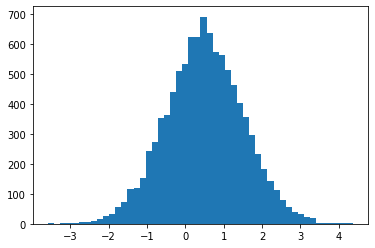

In [113]:
plt.hist(y2,bins=50)

(array([[  1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   1.,
           0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   2.,
           1.,   0.,   1.,   1.,   3.,   4.,   4.,   2.,   2.,   6.,   4.,
           1.,   4.,   7.,   8.,   9.,  11.,   5.,   9.,   9.,  14.,  12.,
          16.,  11.,   9.,  18.,  25.,  30.,  22.,  18.,  28.,  29.,  39.,
          40.,  41.,  37.,  42.,  48.,  56.,  58.,  49.,  80.,  62.,  62.,
          91.,  78.,  75.,  82.,  89.,  81., 106.,  85.,  89., 126., 125.,
         106., 142., 141., 121., 121., 135., 154., 166., 146., 125., 169.,
         160., 170., 172., 162., 161., 161., 193., 146., 186., 170., 166.,
         197., 152., 149., 167., 173., 158., 155., 156., 153., 152., 137.,
         151., 147., 126., 141., 125., 139., 117., 116., 135., 118.,  93.,
         115.,  99.,  78.,  91.,  77.,  63.,  81.,  52.,  83.,  53.,  61.,
          49.,  46.,  46.,  47.,  45.,  26.,  48.,  31.,  27.,  27.,  20.,
          17.,  22.,  15.

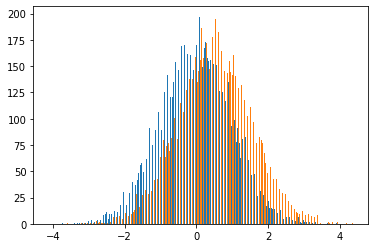

In [183]:
plt.hist([y1,y2],bins=200)

`-` 분포곡선이 나오게 하는 버전도 있던데?.. 

In [184]:
A=pd.DataFrame({'y':y1,'x':['A']*len(y1)})
B=pd.DataFrame({'y':y2,'x':['B']*len(y2)})
df=pd.concat([A,B],ignore_index=True)

/home/cgb4/anaconda3/envs/py38r40/lib/python3.8/site-packages/plotnine/stats/stat_bin.py:95: PlotnineWarning: 'stat_bin()' using 'bins = 84'. Pick better value with 'binwidth'.


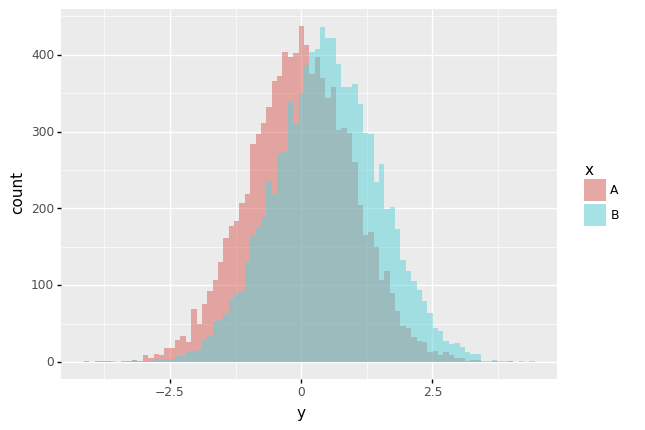

<ggplot: (8754021251365)>

In [187]:
from plotnine import *
ggplot(df)+geom_histogram(aes(x='y',fill='x'),position="identity",alpha=0.5)

In [141]:
sns.histplot?

Signature:
sns.histplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    weights=None,
    stat='count',
    bins='auto',
    binwidth=None,
    binrange=None,
    discrete=None,
    cumulative=False,
    common_bins=True,
    common_norm=True,
    multiple='layer',
    element='bars',
    fill=True,
    shrink=1,
    kde=False,
    kde_kws=None,
    line_kws=None,
    thresh=0,
    pthresh=None,
    pmax=None,
    cbar=False,
    cbar_ax=None,
    cbar_kws=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    color=None,
    log_scale=None,
    legend=True,
    ax=None,
    **kwargs,
)
Docstring:
Plot univariate or bivariate histograms to show distributions of datasets.

A histogram is a classic visualization tool that represents the distribution
of one or more variables by counting the number of observations that fall within
disrete bins.

This function can normalize the statistic computed within each bin to estimate
frequency, density or probability mass